In [44]:
import pandas as pd
import numpy as np
#need to ! pip install pyxlsb
#need to ! pip install openpyxl pour le .xlsx
import matplotlib.pyplot as plt


Dans toute cette étude, nous nous intéressons aux résultats obtenus par le "bloc de gauche" aux élections municipales de 2014 et 2020. 
Nous considérons ici que ce bloc correspond à au groupe Europe Ecologie-Les Verts (LVEC), au groupe Ecologiste (LECO), au groupe Union de la Gauche (LUG), au groupe Divers Gauche (LDVG), au groupe (LSOC) et au groupe Liste du Parti de Gauche (LPG)

In [45]:
#on définit donc le array suivant

BLOC_GAUCHE_ECOLO = [
    'LVEC', 'LVECE',# Europe Ecologie-Les Verts
    'LECO',  # Ecologiste
    'LUG',   # Union de la Gauche
    'LDVG',   # Divers Gauche
    'LSOC',	 #Parti socialiste
    'LPG'	#Liste du Parti de Gauche
]


## Création de la base de donnée relatives aux résultats de l'élection communale de 2020
Pour des fins de comparabilité, nous avons choisit de concentrer notre analyse sur les communes de France métropolitaine (donc sans les données des DROMs, COMs, Terres australes et de Nouvelle Calédonie). Pour ce faire, nous avons récupéré la base de donnée des résultats à laquelle nous avons rajouté la nuance politique da la liste élue par *merging* avec la base de donnée des candidats. Cette donnée n'est disponible que pour les communes de plus de 3 500 habitants 

In [46]:
#Nous faisons le choix d'enlever les DROM, les COM, les Terres australes et la Nouvelle-Calédonie : code de département None ou supérieurs à 900
#le département de corse du sud sera noté 201 au lieu de 2A et haute corse 202 au lieu de 2B
resultats_2020 = pd.read_excel(
    '/home/onyxia/work/Python-project/Data/raw_elections/2020-06-29-resultats-t2-communes-de-1000-hab-et-plus.xlsx',
    header=0,
    dtype={'Code de la commune': str, 'Code du département': str}
)


resultats_2020['Code du département'] = resultats_2020['Code du département'].replace({'2A': '201', '2B': '202'})
resultats_2020['Code du département'] = pd.to_numeric(resultats_2020['Code du département'], errors='coerce')
resultats_2020 = resultats_2020[resultats_2020['Code du département'] < 900]


resultats_2020['Code commune'] = (
    resultats_2020['Code du département'].astype(int).astype(str).str.zfill(2) + 
    resultats_2020['Code de la commune'].astype(str).str.zfill(3)
)
resultats_2020.head(5)

,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,Blancs,...,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Code commune
0,1.0,Ain,034,Belley,5757,2877,49.97,2880,50.03,51,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01034
1,1.0,Ain,160,Ferney-Voltaire,3798,2280,60.03,1518,39.97,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01160
2,1.0,Ain,194,Jassans-Riottier,4357,2689,61.72,1668,38.28,17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01194
3,1.0,Ain,249,Miribel,6847,4064,59.35,2783,40.65,23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01249
4,1.0,Ain,354,Saint-Genis-Pouilly,5015,3108,61.97,1907,38.03,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01354


In [47]:
# Pour chaque commune, nous récupérons le vainqueur de l'élection qui à remporté par définition
# le plus de voix. A la différence d'une base de données où seuls les gagnants sont indiqués, cela
# nous permet de connaitre le pourcentage de voix exprimé en sa faveur

commune_cols = ['Code commune', 'Libellé de la commune']

candidate_fields = [
    'N.Pan.', 'Code Nuance', 'Sexe', 'Nom', 'Prénom', 'Liste',
    'Sièges / Elu', 'Sièges Secteur', 'Sièges CC', 'Voix', '% Voix/Ins', '% Voix/Exp'
]

# Identification des blocs candidats et traitement pour chaque commune
cols = list(resultats_2020.columns)
start = cols.index('N.Pan.') 
k = len(candidate_fields)
nblocks = (len(cols) - start) // k

dfs = []
for b in range(nblocks):
    blk_cols = cols[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k: continue
        
    cand_df = resultats_2020[commune_cols + blk_cols].copy()
    cand_df.columns = commune_cols + candidate_fields
    cand_df = cand_df[cand_df['Nom'].notna()]
    
    dfs.append(cand_df)

long_df_2020 = pd.concat(dfs, ignore_index=True)

long_df_sorted_res = long_df_2020.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

long_df_sorted.head(5)


,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp
0,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99
1,01034,Belley,1.0,LDIV,M,FOGNINI,Jean-Marc,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI,6.0,0.0,4.0,1248.0,21.68,45.01
2,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40
3,01160,Ferney-Voltaire,1.0,LDVC,M,MEYLAN,François,La Force de l'Union,3.0,0.0,0.0,366.0,9.64,24.70
4,01160,Ferney-Voltaire,4.0,LDIV,M,KASTLER,Jean-Loup,FERNEY EN GRAND,3.0,0.0,0.0,369.0,9.72,24.90


In [48]:
# ajout d'une colonne pour sélectionner le gagnant avec un booléen
idx = long_df_2020.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df_2020["winner"] = "no"
long_df_2020.loc[idx, "winner"] = "yes"

long_df_sorted_res = long_df_2020.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

long_df_sorted.head(5)

,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner
0,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99,yes
1,01034,Belley,1.0,LDIV,M,FOGNINI,Jean-Marc,REUNIR POUR BELLEY AVEC JEAN MARC FOGNINI,6.0,0.0,4.0,1248.0,21.68,45.01,no
2,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40,yes
3,01160,Ferney-Voltaire,1.0,LDVC,M,MEYLAN,François,La Force de l'Union,3.0,0.0,0.0,366.0,9.64,24.70,no
4,01160,Ferney-Voltaire,4.0,LDIV,M,KASTLER,Jean-Loup,FERNEY EN GRAND,3.0,0.0,0.0,369.0,9.72,24.90,no


In [49]:
# Sélection du vainqueur pour chaque commune, avec son résultat en pourcentage
long_df_2020['% Voix/Exp'] = pd.to_numeric(long_df_2020['% Voix/Exp'], errors='coerce')
winners_2020 = long_df_2020.loc[long_df_2020.groupby('Code commune')['% Voix/Exp'].idxmax()].copy()

winners_2020['D_elec_2020'] = np.where(
    winners_2020["Code Nuance"].isna(),
    np.nan,
    winners_2020["Code Nuance"].isin(BLOC_GAUCHE_ECOLO).astype(int)
)

print(f"Nombre de communes traitées : {len(winners_2020)}")
display(winners_2020.head())

Nombre de communes traitées : 1340


,Code commune,Libellé de la commune,N.Pan.,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner,D_elec_2020
1340,01034,Belley,4.0,LDVD,M,LAHUERTA,Dimitri,AGIR POUR BELLEY ET BUGEY SUD,23.0,0.0,12.0,1525.0,26.49,54.99,yes,0.0
1341,01160,Ferney-Voltaire,2.0,LDVD,M,RAPHOZ,Daniel,Ferney-Voltaire Valeurs Communes,23.0,0.0,5.0,747.0,19.67,50.40,yes,0.0
3573,01194,Jassans-Riottier,4.0,LDVD,M,REVERCHON,Jean-Pierre,JASSANS LA FORCE D'AGIR ENSEMBLE,23.0,0.0,5.0,856.0,19.65,52.16,yes,0.0
3,01249,Miribel,1.0,LDVD,M,GAITET,Jean-Pierre,"Miribel pour tous, Miribel à tous",23.0,0.0,11.0,1391.0,20.32,50.73,yes,0.0
1344,01354,Saint-Genis-Pouilly,2.0,LDVG,M,BERTRAND,Hubert,"SAINT-GENIS-POUILLY, C'EST VOUS",25.0,0.0,5.0,867.0,17.29,46.12,yes,1.0


In [50]:
#exportations
winners_2020.to_csv('elec_2020.csv', index=False)
long_df_sorted.to_csv('elec_2020_all.csv', index=False)

## Création de la base de donnée relatives aux résultats de l'élection communale de 2014
Comme pour la base précédente, une étape de filtrage est d'abord nécessaire sur la base importée, une adaptation de la base au traitement, on restreint les variables présentes à celles qui nous intéresse et on détermine ensuite l'élu pour chaque commune avec sa nuance politique.

In [51]:
resultats_2014 = pd.read_excel('/home/onyxia/work/Python-project/Data/raw_elections/muni-2014-resultats-com-1000-et-plus-t2.xlsx', header=0)
resultats_2014.head(5)

,Date de l'export,Code du département,Type de scrutin,Libellé du département,Code de la commune,Libellé de la commune,Inscrits,Abstentions,% Abs/Ins,Votants,...,Unnamed: 623,Unnamed: 624,Unnamed: 625,Unnamed: 626,Unnamed: 627,Unnamed: 628,Unnamed: 629,Unnamed: 630,Unnamed: 631,Unnamed: 632
0,2014-03-31 09:33:41,1,LI2,AIN,4,Ambérieu-en-Bugey,8198,3619,44.14,4579,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014-03-31 09:33:41,1,LI2,AIN,7,Ambronay,1770,434,24.52,1336,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014-03-31 09:33:41,1,LI2,AIN,34,Belley,5680,1557,27.41,4123,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014-03-31 09:33:41,1,LI2,AIN,160,Ferney-Voltaire,4070,1882,46.24,2188,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014-03-31 09:33:41,1,LI2,AIN,185,Hauteville-Lompnes,2252,803,35.66,1449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Remplacement des codes Corse
resultats_2014['Code du département'] = resultats_2014['Code du département'].replace({'2A': '201', '2B': '202'})

# Convertir en Int64 et forcer NaN si non convertible
resultats_2014['Code du département'] = pd.to_numeric(resultats_2014['Code du département'], errors='coerce').astype('Int64')

# Supprimer les DROM/COM/TAAF/Nouvelle-Calédonie (codes >900 ou NaN)
resultats_2014 = resultats_2014.dropna(subset=['Code du département'])
resultats_2014 = resultats_2014[resultats_2014['Code du département'] <= 900]

# Créer un code commune unique : 2 chiffres département + 3 chiffres commune
resultats_2014['Code commune'] = (
    resultats_2014['Code du département'].astype(str).str.zfill(2) +
    resultats_2014['Code de la commune'].astype(str).str.zfill(3)
    )


In [53]:
df = resultats_2014.copy()

commune_cols = ['Code commune', 'Libellé de la commune']
candidate_fields = ['Code Nuance','Sexe','Nom','Prénom','Liste',
                    'Sièges / Elu','Sièges Secteur','Sièges CC','Voix','% Voix/Ins','% Voix/Exp']
k = len(candidate_fields)

cols = list(df.columns)
start = cols.index('Code Nuance')
nblocks = (len(cols) - start) // k

dfs = []
for b in range(nblocks):
    blk_cols = cols[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k:
        continue
    cand_df = df[commune_cols + blk_cols].copy()
    cand_df = cand_df.rename(columns=dict(zip(blk_cols, candidate_fields)))
    cand_df = cand_df[cand_df['Nom'].notna() & (cand_df['Nom'].str.strip() != '')]
    dfs.append(cand_df)

long_df = pd.concat(dfs, ignore_index=True)


In [54]:
idx = long_df.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df["winner"] = "no"
long_df.loc[idx, "winner"] = "yes"

long_df_sorted_res = long_df.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_sorted = long_df_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

long_df_sorted.head(5)


,Code commune,Libellé de la commune,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner
0,01004,Ambérieu-en-Bugey,LDVD,M,FABRE,Daniel,PAROLE AUX AMBARROIS,27,0.0,7.0,2678.0,32.67,61.31,yes
1,01004,Ambérieu-en-Bugey,LDVG,F,PIDOUX,Catherine,VIVONS NOTRE VILLE,3,0.0,0.0,741.0,9.04,16.96,no
2,01004,Ambérieu-en-Bugey,LDVG,F,EXPOSITO,Josiane,AMBERIEU AMBITION,3,0.0,1.0,949.0,11.58,21.73,no
3,01007,Ambronay,LDVD,M,FOURNIER,Gabriel,AMBRONAY Demain,1,0.0,0.0,153.0,8.64,11.73,no
4,01007,Ambronay,LDVG,F,LEVRAT,Gisèle,AMBRONAY POUR TOUS,14,0.0,2.0,610.0,34.46,46.78,yes


In [55]:
# Sélection du vainqueur pour chaque commune, avec son résultat en pourcentage
winners_2014 = long_df_sorted.loc[long_df_sorted['winner']=='yes'].reset_index(drop=True)

winners_2014['D_elec_2014'] = np.where(
    winners_2014["Code Nuance"].isna(),
    np.nan,  # keep NaN
    winners_2014["Code Nuance"].isin(BLOC_GAUCHE_ECOLO).astype(int)
)

print(f"Nombre de lignes : {len(winners_2014)}")
display(winners_2014.head(5))

print(winners_2014['Code Nuance'].unique())

Nombre de lignes : 1675


,Code commune,Libellé de la commune,Code Nuance,Sexe,Nom,Prénom,Liste,Sièges / Elu,Sièges Secteur,Sièges CC,Voix,% Voix/Ins,% Voix/Exp,winner,D_elec_2014
0,01004,Ambérieu-en-Bugey,LDVD,M,FABRE,Daniel,PAROLE AUX AMBARROIS,27,0.0,7.0,2678.0,32.67,61.31,yes,0.0
1,01007,Ambronay,LDVG,F,LEVRAT,Gisèle,AMBRONAY POUR TOUS,14,0.0,2.0,610.0,34.46,46.78,yes,1.0
2,01034,Belley,LDVD,M,JIMENEZ,Christian,BELLEY NOUVEL HORIZON 2014,22,0.0,14.0,2029.0,35.72,51.17,yes,0.0
3,01160,Ferney-Voltaire,LDVD,M,RAPHOZ,Daniel,FERNEY-VOLTAIRE VALEURS COMMUNES,22,0.0,4.0,1075.0,26.41,50.45,yes,0.0
4,01185,Hauteville-Lompnes,LUDI,M,ARGENTI,Bernard,OSONS L'AVENIR,22,0.0,6.0,815.0,36.19,61.28,yes,0.0


['LDVD' 'LDVG' 'LUDI' 'LDIV' 'LVEC' 'LFN' 'LUD' 'LSOC' 'LUG' 'LUMP' 'LPG'
 'LFG' 'LCOM' 'LUC' 'LMDM' 'LEXD']


In [56]:
winners_2014.to_csv('elec_2014.csv', index=False)
long_df_sorted.to_csv('elec_2014_all.csv', index=False)

## Statistiques descriptives sur les bases de données 
Pour rappel, nous avons importé les résultats des élections communales de 2020 pour les communes de plus de 3500 habitants, les résultats de 2014. Commençons à comparer ces 2 bases.

In [57]:
blocs = {
    "BLOC_GAUCHE_ECOLO" : [
    'LVECE', # Europe Ecologie-Les Verts
    'LVEC',	#Europe Ecologie-Les Verts
    'LECO',  # Ecologiste
    'LUG',   # Union de la Gauche
    'LDVG',   # Divers Gauche
    'LSOC',	#Parti socialiste
    'LPG'	#Liste du Parti de Gauche
],
    "BLOC_EXT_GAUCHE" : [
    'LEXG',	#Extrême gauche
    'LCOM',	#Parti communiste français
    'LFI',	#La France insoumise
    'LRDG',	#Parti radical de gauche
    'LFG' #Liste Front de Gauche
],
    "BLOC_CENTRE" : [
    'LREM',#	La République en marche
    'LMDM',#	Modem
    'LUC',#	Union du centre
    'LDVC'#	Divers centre
],
    "BLOC_DROITE" : [
    'LLR',#	Les Républicains
    'LUD',#	Union de la droite
    'LDVD',#	Divers droite
    'LUDI',#	Liste Union Démocrates et Indépendants
    'LUMP'#	Liste Union pour un Mouvement Populaire
],
    "BLOC_EXT_DROITE" : [
    'LDLF',#	Debout la France
    'LRN',#	Rassemblement National
    'LEXD',#	Extrême droite
    'LFN'#	Liste Front National
],
    "BLOC_AUTRE" : [
    'LDIV',#	Divers
    'LREG',#	Régionaliste
    'LGJ',#	Gilets jaunes
    'LNC'#	Non Communiqué
]    
}

nuance_to_bloc = {
    nuance: bloc
    for bloc, nuances in blocs.items()
    for nuance in nuances
}

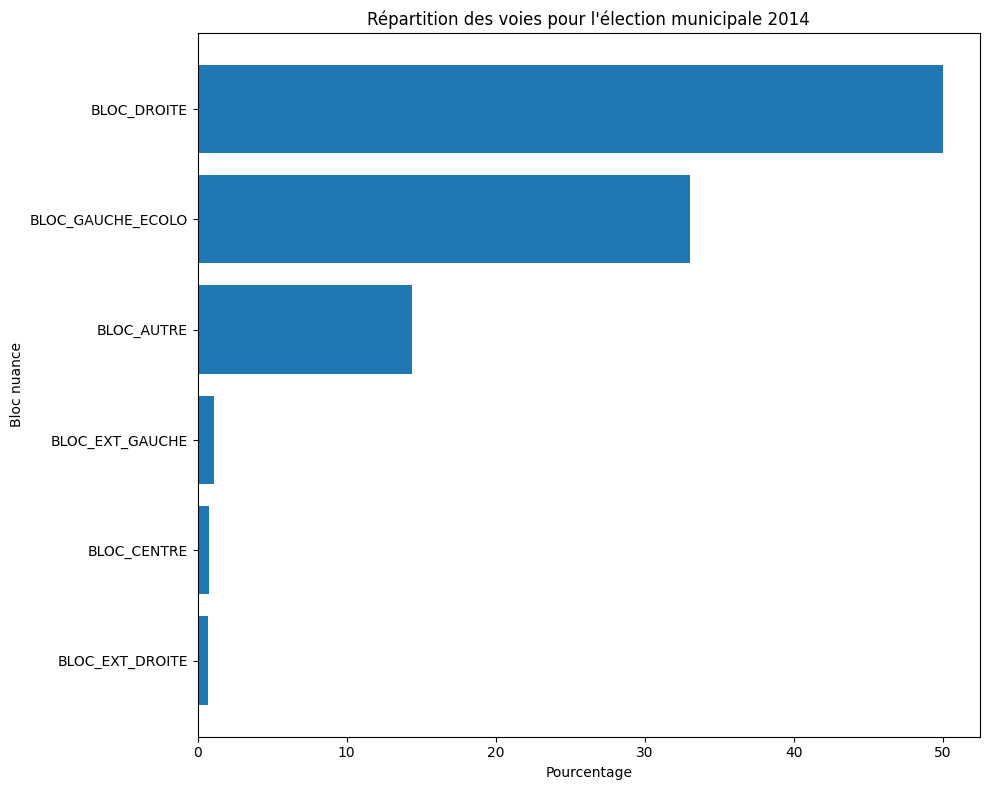

In [58]:
winners_2014["Bloc"] = winners_2014["Code Nuance"].map(nuance_to_bloc)
counts_2014 = (
    winners_2014
    .groupby("Bloc")
    .size()
    .pipe(lambda x: x / x.sum() * 100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(counts_2014.index, counts_2014.values, label="2014")

ax.set_xlabel("Pourcentage")
ax.set_ylabel("Bloc nuance")
ax.set_title("Répartition des voies pour l'élection municipale 2014")

plt.tight_layout()
plt.show()


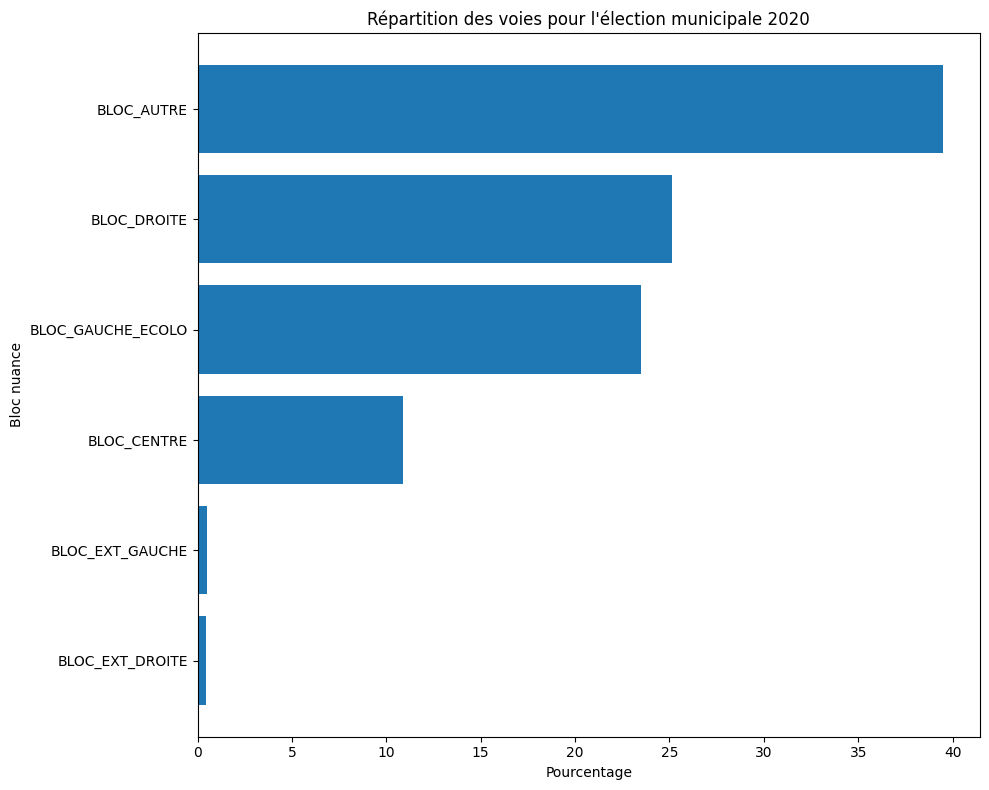

In [59]:
winners_2020["Bloc"] = winners_2020["Code Nuance"].map(nuance_to_bloc)
counts_2020 = (
    winners_2020
    .groupby("Bloc")
    .size()
    .pipe(lambda x: x / x.sum() * 100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(counts_2020.index, counts_2020.values)

ax.set_xlabel("Pourcentage")
ax.set_ylabel("Bloc nuance")
ax.set_title("Répartition des voies pour l'élection municipale 2020")

plt.tight_layout()
plt.show()

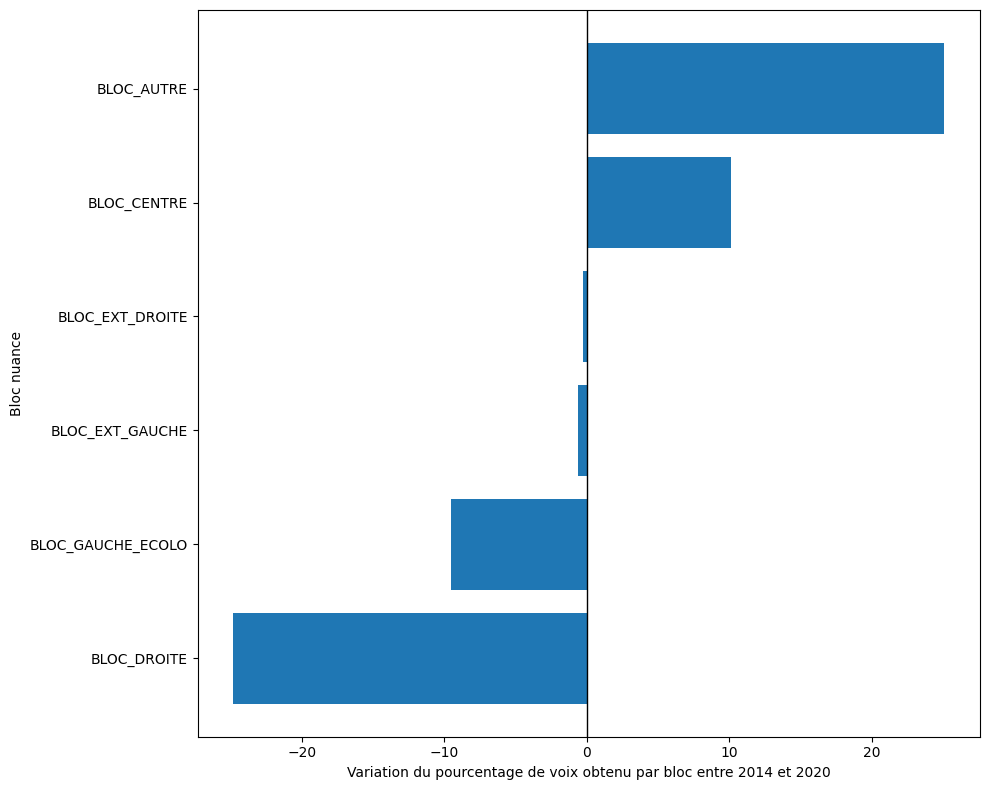

In [60]:
d_count = pd.concat([counts_2014, counts_2020], axis=1)
d_count.columns = ["2014", "2020"]
d_count = d_count.fillna(0)
d_count['Evol_percent'] = d_count['2020'] - d_count['2014']
d_count = d_count.sort_values(by=['Evol_percent'])

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(d_count.index, d_count['Evol_percent'])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Variation du pourcentage de voix obtenu par bloc entre 2014 et 2020")
ax.set_ylabel("Bloc nuance")

plt.tight_layout()
plt.show()

La période entre 2014 et 2020 est marquée par une grande variations dans les listes présentées par les candidats aux élections municipales.

Lors de l'élection de 2014, le panel de candidat est dominé par les nuances traditionnelles "Divers Droite" et "Divers gauche". Au global, les nuances du bloc gauche et du bloc droite remporte près de 80% des communes de plus de 3 500 habitants.

En 2020, les résultats du bloc centre sont boostée par l'arrivée du partie LREM, qui participe à l'érosion des résultats du bloc de droite. Aussi, ce graphe rend compte de l'incomplétude nos données, car la forte progression du bloc autre s'explique en grande partie par l'accroissement significatif du nombre de communes n'ayant pas communiqué la nuance politique de leurs élus.

## Introduction des résultats aux présidentielles 
Nous introduisons les données des 1ers tours des présidentielles de 2022 et 2017 par communes pour affiner notre analyse. Ces données présentes certaines difficultés, les communes sont identifiés par code INSEE et non code postal et les code partis ne sont pas renseignés, seuls les candidats le sont. 

In [61]:
resultats_2022 = pd.read_excel('/home/onyxia/work/Python-project/Data/data_pour_nos_codes/bin/Elections présidentielles 2022 par commune.xlsx', header=0)
resultats_2022.head(5)



,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,...,Unnamed: 93,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102
0,01,Ain,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,83.26,...,3,0.47,0.58,12,M,DUPONT-AIGNAN,Nicolas,21,3.26,4.04
1,01,Ain,2,L'Abergement-de-Varey,Complet,213,38,17.84,175,82.16,...,3,1.41,1.75,12,M,DUPONT-AIGNAN,Nicolas,0,0.00,0.00
2,01,Ain,4,Ambérieu-en-Bugey,Complet,8765,2078,23.71,6687,76.29,...,43,0.49,0.66,12,M,DUPONT-AIGNAN,Nicolas,181,2.07,2.76
3,01,Ain,5,Ambérieux-en-Dombes,Complet,1282,234,18.25,1048,81.75,...,2,0.16,0.19,12,M,DUPONT-AIGNAN,Nicolas,27,2.11,2.63
4,01,Ain,6,Ambléon,Complet,103,23,22.33,80,77.67,...,0,0.00,0.00,12,M,DUPONT-AIGNAN,Nicolas,1,0.97,1.30


In [62]:
#On filtre d'abord aux communes qui nous intéressent
df = pd.DataFrame(resultats_2022)
print(df['Code du département'].dtype)


resultats_2022['Code du département'] = pd.to_numeric(resultats_2022['Code du département'], errors='coerce')
resultats_2022 = resultats_2022[resultats_2022['Code du département'] < 900]


resultats_2022['Code commune'] = (
    resultats_2022['Code du département'].astype(int).astype(str).str.zfill(2) + 
    resultats_2022['Code de la commune'].astype(str).str.zfill(3)
)
resultats_2022.head()

object


,Code du département,Libellé du département,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,% Vot/Ins,...,Unnamed: 94,Unnamed: 95,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Code commune
0,1.0,Ain,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,83.26,...,0.47,0.58,12,M,DUPONT-AIGNAN,Nicolas,21,3.26,4.04,01001
1,1.0,Ain,2,L'Abergement-de-Varey,Complet,213,38,17.84,175,82.16,...,1.41,1.75,12,M,DUPONT-AIGNAN,Nicolas,0,0.00,0.00,01002
2,1.0,Ain,4,Ambérieu-en-Bugey,Complet,8765,2078,23.71,6687,76.29,...,0.49,0.66,12,M,DUPONT-AIGNAN,Nicolas,181,2.07,2.76,01004
3,1.0,Ain,5,Ambérieux-en-Dombes,Complet,1282,234,18.25,1048,81.75,...,0.16,0.19,12,M,DUPONT-AIGNAN,Nicolas,27,2.11,2.63,01005
4,1.0,Ain,6,Ambléon,Complet,103,23,22.33,80,77.67,...,0.00,0.00,12,M,DUPONT-AIGNAN,Nicolas,1,0.97,1.30,01006


In [63]:
# Pour chaque commune, nous récupérons les résultats pour chacun des candidats

commune_cols_2022 = ['Code du département', 'Libellé du département', 'Code commune', 'Code de la commune',
'Libellé de la commune', 'Etat saisie', 'Inscrits', 'Abstentions','% Abs/Ins', 'Votants',	'% Vot/Ins', 'Blancs',	
 '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot'
]

candidate_fields_2022 = ["N°Panneau", "Sexe", "Nom", "Prénom", "Voix", "% Voix/Ins", "% Voix/Exp"
]
# Identification des blocs candidats et traitement pour chaque commune
cols_2022 = list(resultats_2022.columns)
start = cols_2022.index("N°Panneau") 
k = len(candidate_fields_2022)
nblocks = (len(cols) - start) // k

dfs = []
for b in range(nblocks):
    blk_cols = cols_2022[start + b*k : start + (b+1)*k]
    if len(blk_cols) < k: continue
        
    cand_df = resultats_2022[commune_cols_2022 + blk_cols].copy()
    cand_df.columns = commune_cols_2022 + candidate_fields_2022
    cand_df = cand_df[cand_df['Nom'].notna()]
    
    dfs.append(cand_df)

long_df_2022 = pd.concat(dfs, ignore_index=True)

long_df_2022_sorted_res = long_df_2022.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

long_df_2022_sorted = long_df_2022_sorted_res.sort_values(
    by=['Code commune']
).reset_index(drop=True)

df_clean = long_df_2022_sorted.drop(columns=['Code du département','Etat saisie', 'Inscrits', 'Abstentions','% Abs/Ins', 'Votants',	'% Vot/Ins', 'Blancs',	
 '% Blancs/Ins', '% Blancs/Vot', 'Nuls', '% Nuls/Ins', '% Nuls/Vot', 'Exprimés', '% Exp/Ins', '% Exp/Vot'])

long_df_2022_sorted.head(11)

,Code du département,Libellé du département,Code commune,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,...,Exprimés,% Exp/Ins,% Exp/Vot,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp
0,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,8,F,HIDALGO,Anne,5,0.78,0.96
1,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,3,M,MACRON,Emmanuel,150,23.26,28.85
2,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,4,M,LASSALLE,Jean,18,2.79,3.46
3,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,9,M,JADOT,Yannick,30,4.65,5.77
4,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,11,M,POUTOU,Philippe,3,0.47,0.58
5,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,1,F,ARTHAUD,Nathalie,3,0.47,0.58
6,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,12,M,DUPONT-AIGNAN,Nicolas,21,3.26,4.04
7,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,5,F,LE PEN,Marine,149,23.10,28.65
8,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,2,M,ROUSSEL,Fabien,6,0.93,1.15
9,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,10,F,PÉCRESSE,Valérie,26,4.03,5.00


In [64]:

idx = long_df_2022_sorted.groupby("Code commune")["% Voix/Exp"].idxmax()
long_df_2022_sorted["winner"] = "no"
long_df_2022_sorted.loc[idx, "winner"] = "yes"

long_df_2022_sorted_res = long_df_2022_sorted.sort_values(
    by=['% Voix/Exp'], ascending=False
).reset_index(drop=True)

# Créer un nouveau dataframe trié
df_trie = long_df_2022_sorted_res.sort_values(by=['Code commune', '% Voix/Exp'], ascending=[True, False])

# Afficher les 5 premières lignes pour vérifier
df_trie.head(5)

,Code du département,Libellé du département,Code commune,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,...,% Exp/Ins,% Exp/Vot,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp,winner
28865,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,80.62,96.83,3,M,MACRON,Emmanuel,150,23.26,28.85,yes
29575,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,80.62,96.83,5,F,LE PEN,Marine,149,23.10,28.65,no
96236,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,80.62,96.83,7,M,MÉLENCHON,Jean-Luc,66,10.23,12.69,no
120419,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,80.62,96.83,6,M,ZEMMOUR,Éric,43,6.67,8.27,no
152459,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,80.62,96.83,9,M,JADOT,Yannick,30,4.65,5.77,no


In [65]:

df_work = long_df_2022_sorted.copy()

# (Optionnel) Reset de l'index au début pour être sûr que idxmax renvoie des index valides
df_work = df_work.reset_index(drop=True)

# 2. On trouve l'index de la ligne ayant le score max pour chaque commune
idx_winners = df_work.groupby("Code commune")["% Voix/Exp"].idxmax()

# 3. On initialise la colonne à "no" partout
df_work["winner"] = "no"

# 4. On passe à "yes" uniquement les lignes identifiées dans idx_winners
df_work.loc[idx_winners, "winner"] = "yes"

# 5. Tri final : 
# On trie par 'Code commune' (croissant) 
# ET par '% Voix/Exp' (décroissant) pour que le gagnant soit toujours la 1ère ligne de la commune
df_final = df_work.sort_values(by=['Code commune', '% Voix/Exp'], ascending=[True, False])

# Affichage
df_final.head(10)

# On ne garde que les lignes où winner est égal à "yes"
df_vainqueurs = df_final[df_final["winner"] == "yes"].copy()

# (Optionnel) On enlève la colonne 'winner' car elle ne sert plus à rien (tout est à 'yes')
df_vainqueurs.drop(columns=["winner"], inplace=True)

# Vérification
df_vainqueurs.head()

,Code du département,Libellé du département,Code commune,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,...,Exprimés,% Exp/Ins,% Exp/Vot,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp
1,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,520,80.62,96.83,3,M,MACRON,Emmanuel,150,23.26,28.85
14,1.0,Ain,01002,2,L'Abergement-de-Varey,Complet,213,38,17.84,175,...,171,80.28,97.71,3,M,MACRON,Emmanuel,50,23.47,29.24
34,1.0,Ain,01004,4,Ambérieu-en-Bugey,Complet,8765,2078,23.71,6687,...,6553,74.76,98.00,5,F,LE PEN,Marine,1646,18.78,25.12
46,1.0,Ain,01005,5,Ambérieux-en-Dombes,Complet,1282,234,18.25,1048,...,1028,80.19,98.09,5,F,LE PEN,Marine,352,27.46,34.24
55,1.0,Ain,01006,6,Ambléon,Complet,103,23,22.33,80,...,77,74.76,96.25,3,M,MACRON,Emmanuel,21,20.39,27.27


In [66]:
Parti_politique = {
    'MACRON': 'LREM',  
    'LE PEN': 'LFN',    
    'MÉLENCHON': 'LUG',  
    'ZEMMOUR': 'LEXD',
    'PÉCRESSE': 'LLR', 
    'JADOT': 'LVEC',
    'LASSALLE': 'LDVD',
    'ROUSSEL': 'LCOM',
    'DUPONT-AIGNAN': 'LDVD',
    'HIDALGO': 'LSOC',
    'POUTOU': 'LEXG',
    'ARTHAUD': 'LEXG'
}

# 2. Créer la colonne
df_vainqueurs['code nuance'] = df_vainqueurs['Nom'].map(Parti_politique)
df_vainqueurs.head()

,Code du département,Libellé du département,Code commune,Code de la commune,Libellé de la commune,Etat saisie,Inscrits,Abstentions,% Abs/Ins,Votants,...,% Exp/Ins,% Exp/Vot,N°Panneau,Sexe,Nom,Prénom,Voix,% Voix/Ins,% Voix/Exp,code nuance
1,1.0,Ain,01001,1,L'Abergement-Clémenciat,Complet,645,108,16.74,537,...,80.62,96.83,3,M,MACRON,Emmanuel,150,23.26,28.85,LREM
14,1.0,Ain,01002,2,L'Abergement-de-Varey,Complet,213,38,17.84,175,...,80.28,97.71,3,M,MACRON,Emmanuel,50,23.47,29.24,LREM
34,1.0,Ain,01004,4,Ambérieu-en-Bugey,Complet,8765,2078,23.71,6687,...,74.76,98.00,5,F,LE PEN,Marine,1646,18.78,25.12,LFN
46,1.0,Ain,01005,5,Ambérieux-en-Dombes,Complet,1282,234,18.25,1048,...,80.19,98.09,5,F,LE PEN,Marine,352,27.46,34.24,LFN
55,1.0,Ain,01006,6,Ambléon,Complet,103,23,22.33,80,...,74.76,96.25,3,M,MACRON,Emmanuel,21,20.39,27.27,LREM


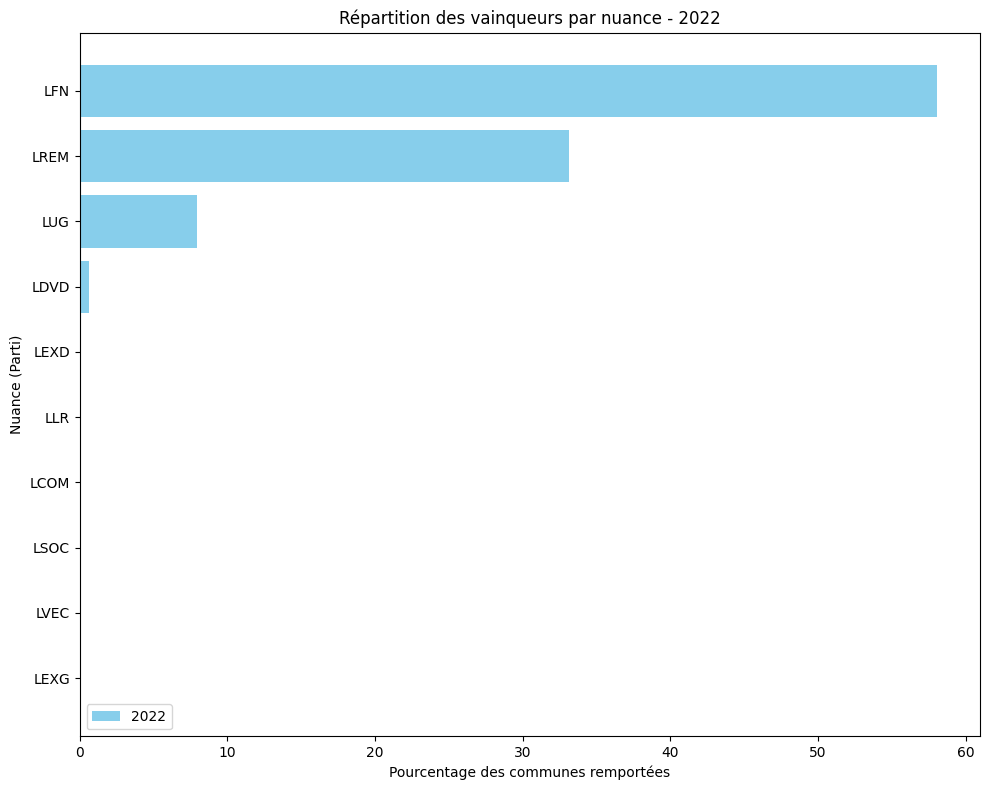

In [67]:
counts_2022 = df_vainqueurs['code nuance'].value_counts(normalize=True) * 100 

# 2. Tri décroissant
counts_2022 = counts_2022.sort_values(ascending=True)

# 3. Création du graphique
fig, ax = plt.subplots(figsize=(10, 8))

# Affichage des barres
ax.barh(counts_2022.index, counts_2022.values, label="2022", color='skyblue')

# 4. Habillage
ax.set_xlabel("Pourcentage des communes remportées")
ax.set_ylabel("Nuance (Parti)")
ax.set_title("Répartition des vainqueurs par nuance - 2022")
ax.legend()

plt.tight_layout()
plt.show()

In [68]:
#Affichage du nombre de villes ayant voté pour chacun des candidats
print(df_vainqueurs['Nom'].unique())

# 1. Calcul des comptes (Nombre de communes gagnées par candidat)
victoires_par_candidat = df_vainqueurs['Nom'].value_counts()

# 2. Création d'un tableau propre (DataFrame)
tableau_res = pd.DataFrame({
    'Candidat': victoires_par_candidat.index,
    'Nombre de Communes': victoires_par_candidat.values,
    'Pourcentage (%)': (victoires_par_candidat.values / len(df_vainqueurs) * 100).round(2)
})

# 3. Ajout de la nuance (pour information)
# On récupère le mapping depuis ton dictionnaire existant
tableau_res['Nuance'] = tableau_res['Candidat'].map(Parti_politique)

# 4. Affichage du tableau
print(f"Total des communes traitées : {len(df_vainqueurs)}")
display(tableau_res)


['MACRON' 'LE PEN' 'MÉLENCHON' 'ARTHAUD' 'ROUSSEL' 'ZEMMOUR' 'PÉCRESSE'
 'LASSALLE' 'HIDALGO' 'DUPONT-AIGNAN' 'JADOT' 'POUTOU']
Total des communes traitées : 34460


,Candidat,Nombre de Communes,Pourcentage (%),Nuance
0,LE PEN,20011,58.07,LFN
1,MACRON,11417,33.13,LREM
2,MÉLENCHON,2732,7.93,LUG
3,LASSALLE,212,0.62,LDVD
4,ZEMMOUR,31,0.09,LEXD
5,PÉCRESSE,24,0.07,LLR
6,ROUSSEL,10,0.03,LCOM
7,HIDALGO,9,0.03,LSOC
8,JADOT,8,0.02,LVEC
9,DUPONT-AIGNAN,4,0.01,LDVD


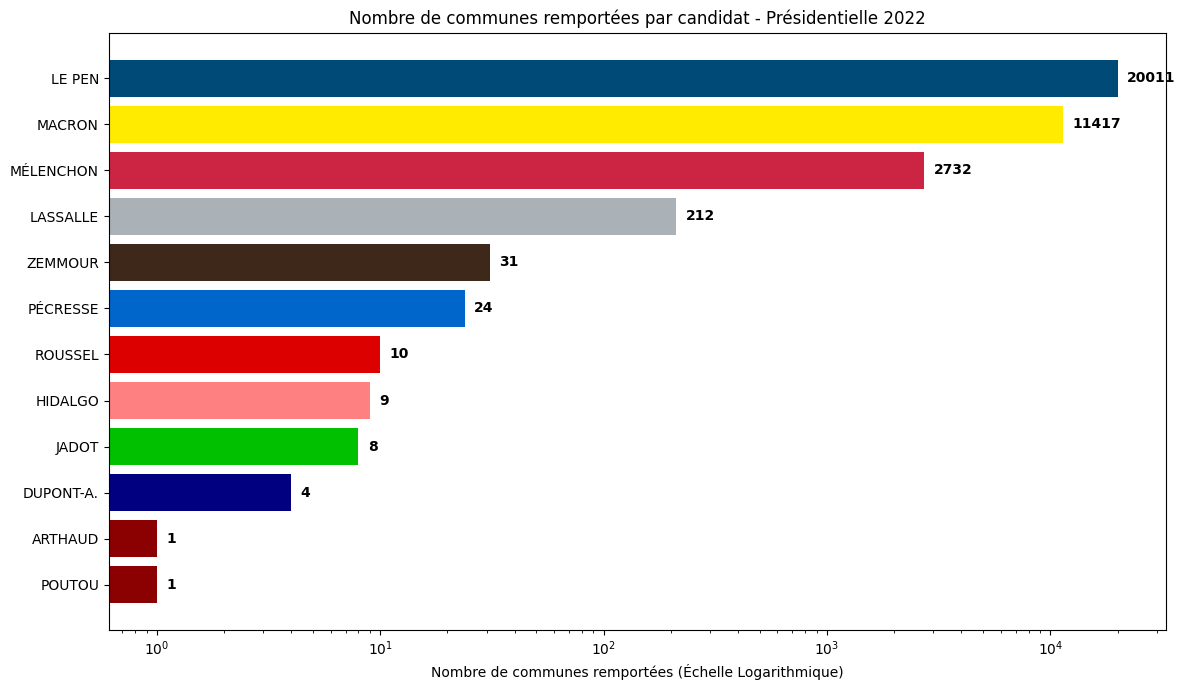

In [69]:
#On tente de faire ressortir sur un graphique à échelle logarithmique le nombre de villes par candidats
candidats = ['LE PEN', 'MACRON', 'MÉLENCHON', 'LASSALLE', 'ZEMMOUR', 'PÉCRESSE', 'ROUSSEL', 'HIDALGO', 'JADOT', 'DUPONT-A.', 'ARTHAUD', 'POUTOU']
valeurs = [20011, 11417, 2732, 212, 31, 24, 10, 9, 8, 4, 1, 1]

# Couleurs politiques standardisées
couleurs = [
    '#004a77', # Le Pen (Bleu fonce)
    '#ffeb00', # Macron (Jaune/Orange LREM)
    '#cc2443', # Melenchon (Rouge LFI)
    '#aab1b7', # Lassalle (Gris)
    '#3d2819', # Zemmour (Brun)
    '#0066cc', # Pecresse (Bleu LR)
    '#dd0000', # Roussel (Rouge PCF)
    '#ff8080', # Hidalgo (Rose PS)
    '#00c000', # Jadot (Vert)
    '#000080', # NDA (Bleu nuit)
    '#8b0000', # Arthaud (Rouge sombre)
    '#8b0000'  # Poutou
]

fig, ax = plt.subplots(figsize=(12, 7))

# Création des barres
y_pos = np.arange(len(candidats))
ax.barh(y_pos, valeurs, color=couleurs, align='center')

# --- Echelle Logarithmique ---
ax.set_xscale('log') 

# On ordonne dans l'ordre décroissant
ax.set_yticks(y_pos)
ax.set_yticklabels(candidats)
ax.invert_yaxis()  

ax.set_xlabel('Nombre de communes remportées (Échelle Logarithmique)')
ax.set_title('Nombre de communes remportées par candidat - Présidentielle 2022')

#On ajoute les valeurs exactes de villes remportées après chacune des barres
for i, v in enumerate(valeurs):
    ax.text(v * 1.1, i, str(v), color='black', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

#### Présidentielles de 2017
Importation et traitement, lecture des données relatives à l'élection de 2017